In [2]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [3]:
import pandas as pd
import seaborn as sb

from pathlib import Path
from uncertainties import ufloat
from scipy.stats import norm

from pytransit.lpf.tesslpf import TESSLPF, fold, downsample_time
from pytransit.orbits import epoch

In [4]:
npop         = 30
mcmc_repeats = 4
datadir = 'data/WASP-11b/MAST_2022-01-02T0720/TESS/tess2021232031932-s0042-0000000085593751-0213-s/'
tic = '85593751'
zero_epoch = ufloat(2454473.0588,2e-4)
period = ufloat(3.722465,7e-6)

In [5]:
lpf = TESSLPF('WASP-11b',datadir,tic=tic,zero_epoch=zero_epoch.n,period=period.n,use_pdc=False,nsamples=2, bldur=0.25)
ep = epoch(lpf.times[0].mean(), lpf.zero_epoch, lpf.period)
tc = zero_epoch + ep*period

lpf.set_prior('tc', 'NP', tc.n,     0.05)          # Wide normal prior on the transit center
lpf.set_prior('p',  'NP', period.n, 1e4*period.s)  # Wide normal prior on the orbital period
lpf.set_prior('rho', 'UP', 1, 3.0)               # Uniform prior on the stellar density
lpf.set_prior('k2', 'UP', 0.0, 0.2**2)             # Uniform prior on the area ratio
lpf.set_prior('gp_ln_in', 'UP', -2, 1)             # Uniform prior on the GP input scale

### Print the model parameters

In [6]:
lpf.print_parameters(columns=1)

  0 |G| tc             N(μ = 2459449.9945050003, σ = 0.05)      [    -inf ..      inf]
  1 |G| p              N(μ = 3.722465, σ = 0.06999999999999999) [    0.00 ..      inf]
  2 |G| rho            U(a = 1, b = 3.0)                        [    0.00 ..      inf]
  3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00]
  4 |P| k2             U(a = 0.0, b = 0.04000000000000001)      [    0.00 ..      inf]
  5 |P| q1_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  6 |P| q2_TESS        U(a = 0, b = 1)                          [    0.00 ..     1.00]
  7 |L| gp_ln_out      N(μ = -6.0, σ = 1.5)                     [    -inf ..      inf]
  8 |L| gp_ln_in       U(a = -2, b = 1)                         [    -inf ..      inf]
  9 |L| gp_log10_wn    N(μ = -2.761221827443316, σ = 0.025)     [    -inf ..      inf]


## Global optimisation

We'll start with a global optimisation run to clump the parameter vector population near the global posterior mode and plot the mode.

This can be done semi-interactively. That is, first run the optimiser (evaluate the cell below) with a small (100-300) number of iterations and plot the folded transit. Then run the optimiser again (re-evaluate the cell below, and the optimiser continues from where it left) and replot the folded transit. After it's clear that the optimiser is converging to a sensible solution, run the optimiser longer (possibly until it stops).

**Note:** The parameter vector population size `npop` should be at least twice the number of free parameters (`len(lpf.ps)`).

Global optimisation:   0%|          | 0/150 [00:00<?, ?it/s]

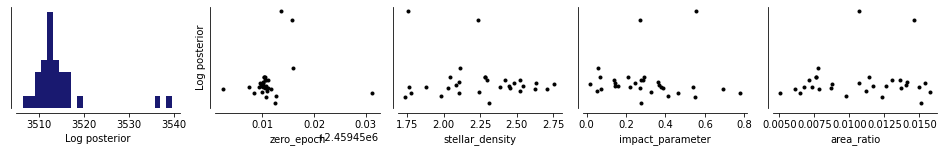

In [7]:
lpf.optimize_global(150, npop=npop)

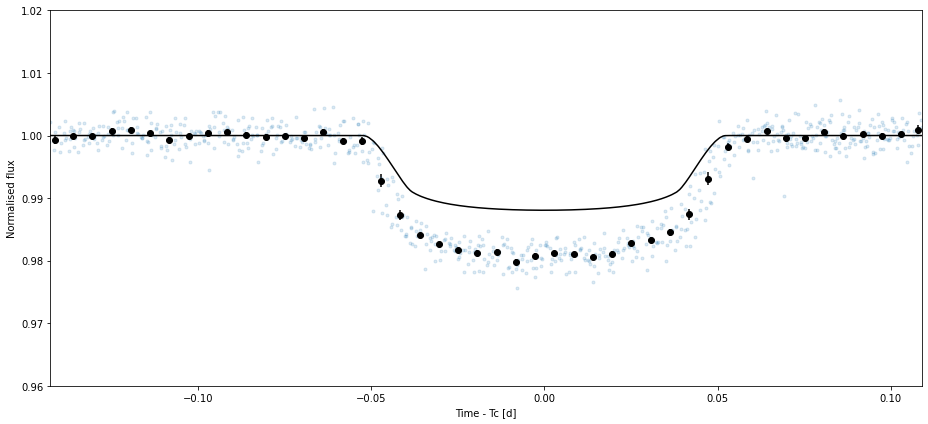

In [8]:
lpf.plot_folded_transit(ylim=(0.96, 1.02));

## MCMC

### Sample the posterior
We continue with an MCMC run, using the global optimisation population as the MCMC starting population. The MCMC sampling consists of a set of wamp-up runs where each run is started from the parameter vector population of the previous run's last iteration, and the chains from the previous run are discarded.

In [9]:
lpf.sample_mcmc(2500, thin=25, repeats=mcmc_repeats)

MCMC sampling:   0%|          | 0/4 [00:00<?, ?it/s]

Run 1/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 2/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 3/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Run 4/4:   0%|          | 0/2500 [00:00<?, ?it/s]

## Analysis
### Plot the posterior model

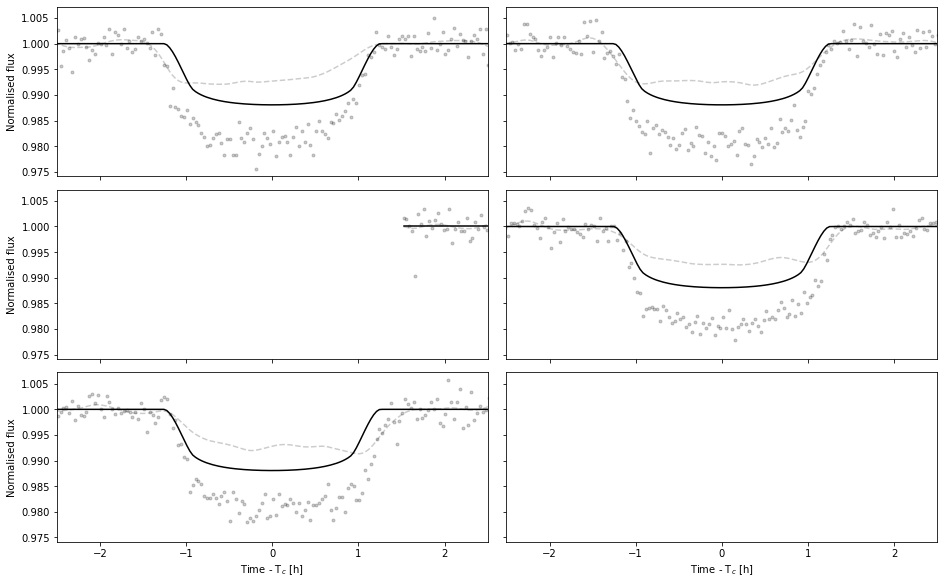

In [10]:
fig = lpf.plot_individual_transits(ncols=2, figsize=(13,8), xlim=(-2.5,2.5))

### Plot the posterior transit centre

In [11]:
df = lpf.posterior_samples()

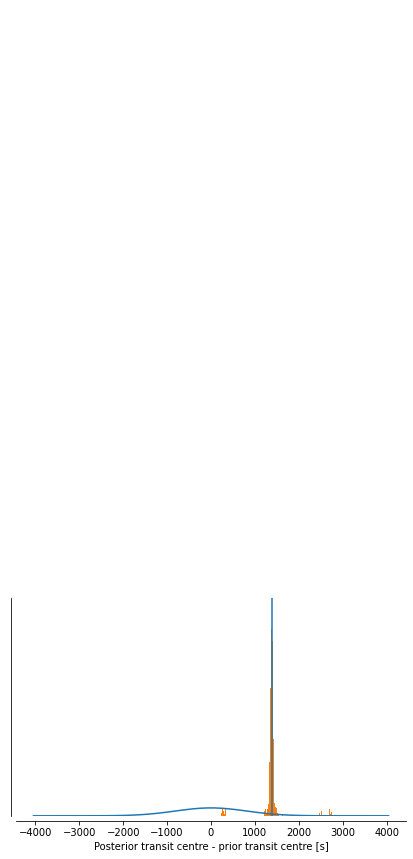

In [12]:
df = lpf.posterior_samples()
fig, ax = subplots(figsize=(7,4), constrained_layout=True)
d_to_s = 24*60*60
tc_diff = d_to_s*(df.tc-tc.n)
tc_diff_m = median(tc_diff)
x = linspace(- 5*tc.s, 5*tc.s)
ax.plot(d_to_s*x, norm(0, d_to_s*tc.s).pdf(d_to_s*x));
ax.hist(tc_diff, density=True, bins='auto')
ax.axvline(tc_diff_m)
ax.annotate(f'{tc_diff_m:.2f} ± {tc_diff.std():.2f} s', (tc_diff_m, 0.05), ((tc_diff_m+3, 0.05)))
setp(ax, xlabel='Posterior transit centre - prior transit centre [s]', yticks=[])
sb.despine(fig, offset=5)

### The default corner plot

Everyone likes corner plots, so let's do one for the main parameters.

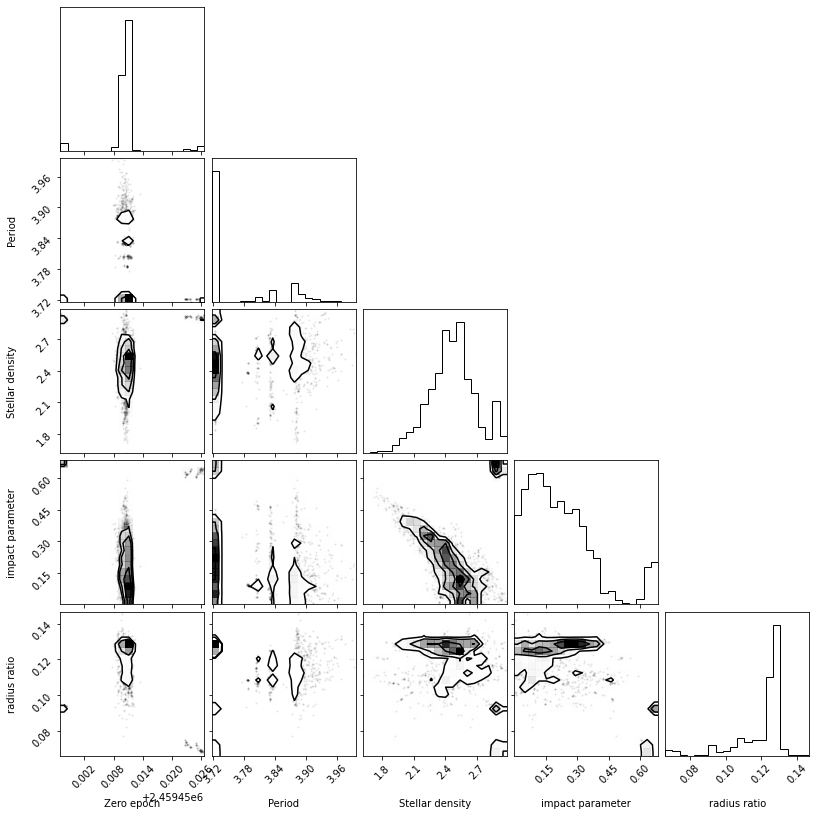

In [13]:
lpf.plot_basic_posteriors()